#**<font color = "FF9900">Mô Tả Bài Toán</font>**
---



Nguồn dữ liệu: https://fraud-detection-handbook.github.io/fraud-detection-handbook/Foreword.html

Dữ liệu thô: https://github.com/Fraud-Detection-Handbook/simulated-data-raw

Chuyển đổi dữ liệu thô: https://github.com/Fraud-Detection-Handbook/simulated-data-transformed




# <font color = "FF6666">Connect Drive</font>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# đường dẫn thư mục sẽ làm việc
WorkingPath ="/content/drive/MyDrive/TAI_LIEU_CUA_THAM/ThucTap_VinSmartFuture/Fraud-Detection-Handbook/"
%cd $WorkingPath

%pwd

/content/drive/MyDrive/TAI_LIEU_CUA_THAM/ThucTap_VinSmartFuture/Fraud-Detection-Handbook


'/content/drive/MyDrive/TAI_LIEU_CUA_THAM/ThucTap_VinSmartFuture/Fraud-Detection-Handbook'

# <font color = "FF6666">Import Libraries</font>

In [7]:
!pip install skorch

In [8]:
# Import necessary python libraries
import os
import random
import pandas as pd
import numpy as np

import torch

import matplotlib.pyplot as plt

# <font color = "FF6666">1. Dataset</font>

In [ ]:
# Load shared functions
#!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

In [ ]:
# tải dữ liệu sau khi đã được tiền xử lý
DIR_INPUT='1_Fraud-Detection-Handbook_simulated-data-raw/data/'

BEGIN_DATE = "2018-04-01"
END_DATE = "2018-09-30"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

transactions_df.head(3)

Load  files
CPU times: user 7.6 s, sys: 462 ms, total: 8.06 s
Wall time: 16.9 s
1754155 transactions loaded, containing 14681 fraudulent transactions


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0


# <font color = "FF6666">2. EDA (Exploratory Data Analysis) - Phân tích khám phá dữ liệu</font>

In [ ]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        int64         
 3   TERMINAL_ID        int64         
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    int64         
 6   TX_TIME_DAYS       int64         
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(7)
memory usage: 120.4 MB


In [ ]:
transactions_df.isnull().sum()

,0
TRANSACTION_ID,0
TX_DATETIME,0
CUSTOMER_ID,0
TERMINAL_ID,0
TX_AMOUNT,0
TX_TIME_SECONDS,0
TX_TIME_DAYS,0
TX_FRAUD,0
TX_FRAUD_SCENARIO,0


In [ ]:
transactions_df.duplicated().sum()

np.int64(0)

In [ ]:
number_type = [f for f in transactions_df.columns if transactions_df.dtypes[f] != 'object']
print ("các cột đã là dạng số:", number_type)

object_type = [f for f in transactions_df.columns if transactions_df.dtypes[f] == 'object']
print ("các cột đang là dạng string:", object_type)

các cột đã là dạng số: ['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD', 'TX_FRAUD_SCENARIO']
các cột đang là dạng string: []


In [ ]:
# Analyze basic statistics of each column
transactions_df['TX_AMOUNT'].describe()

,TX_AMOUNT
count,1.754155e+06
mean,5.363230e+01
std,4.232649e+01
min,0.000000e+00
25%,2.101000e+01
50%,4.464000e+01
75%,7.695000e+01
max,2.628000e+03


In [ ]:
%%capture

distribution_amount_times_fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_AMOUNT'].sample(n=10000).values
time_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_TIME_SECONDS'].sample(n=10000).values

sns.distplot(amount_val, ax=ax[0], color='r', hist = True, kde = False)
ax[0].set_title('Distribution of transaction amounts', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
ax[0].set(xlabel = "Amount", ylabel="Number of transactions")

# We divide the time variables by 86400 to transform seconds to days in the plot
sns.distplot(time_val/86400, ax=ax[1], color='b', bins = 100, hist = True, kde = False)
ax[1].set_title('Distribution of transaction times', fontsize=14)
ax[1].set_xlim([min(time_val/86400), max(time_val/86400)])
ax[1].set_xticks(range(10))
ax[1].set(xlabel = "Time (days)", ylabel="Number of transactions")

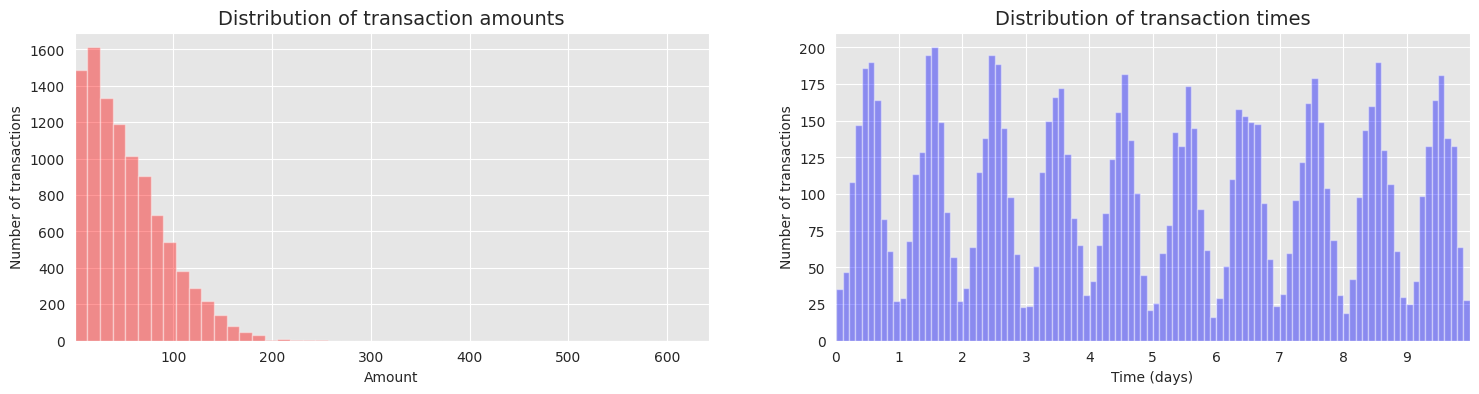

In [ ]:
distribution_amount_times_fig

In [ ]:
def get_stats(transactions_df):
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraud_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_fraudcard_per_day=transactions_df[transactions_df['TX_FRAUD']>0].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()

    return (nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)

(nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)=get_stats(transactions_df)

n_days=len(nb_tx_per_day)
tx_stats=pd.DataFrame({"value":pd.concat([nb_tx_per_day/50,nb_fraud_per_day,nb_fraudcard_per_day])})
tx_stats['stat_type']=["nb_tx_per_day"]*n_days+["nb_fraud_per_day"]*n_days+["nb_fraudcard_per_day"]*n_days
tx_stats=tx_stats.reset_index()

In [ ]:
%%capture

sns.set(style='darkgrid')
sns.set(font_scale=1.4)

fraud_and_transactions_stats_fig = plt.gcf()

fraud_and_transactions_stats_fig.set_size_inches(15, 8)

sns_plot = sns.lineplot(x="TX_TIME_DAYS", y="value", data=tx_stats, hue="stat_type", hue_order=["nb_tx_per_day","nb_fraud_per_day","nb_fraudcard_per_day"], legend=False)

sns_plot.set_title('Total transactions, and number of fraudulent transactions \n and number of compromised cards per day', fontsize=20)
sns_plot.set(xlabel = "Number of days since beginning of data generation", ylabel="Number")

sns_plot.set_ylim([0,300])

labels_legend = ["# transactions per day (/50)", "# fraudulent txs per day", "# fraudulent cards per day"]

sns_plot.legend(loc='upper left', labels=labels_legend,bbox_to_anchor=(1.05, 1), fontsize=15)

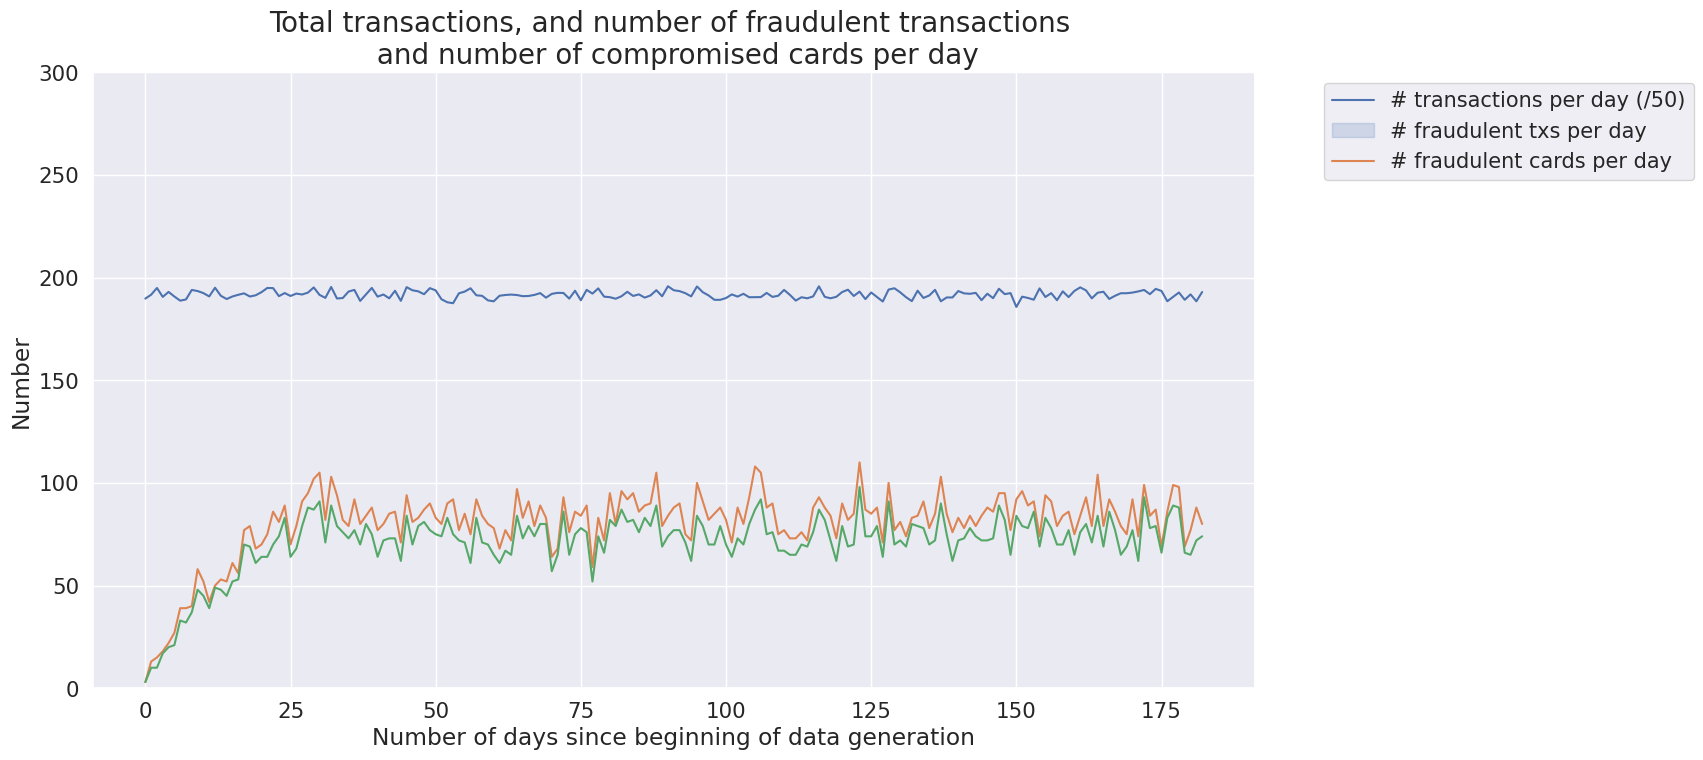

In [ ]:
fraud_and_transactions_stats_fig

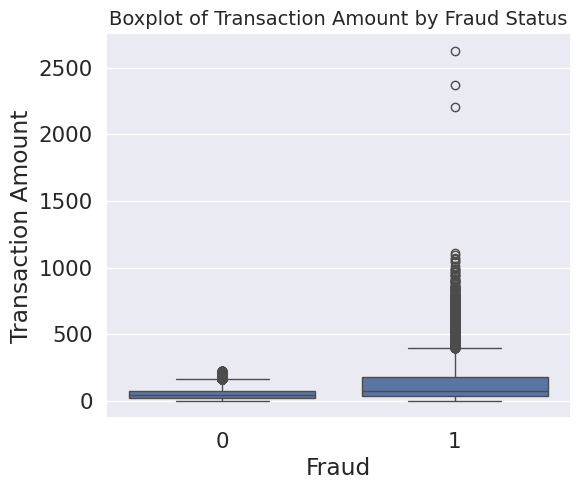

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(
    data=transactions_df,
    x='TX_FRAUD',
    y='TX_AMOUNT'
)
plt.xlabel('Fraud')
plt.ylabel('Transaction Amount')
plt.title('Boxplot of Transaction Amount by Fraud Status', fontsize=14)
plt.show()

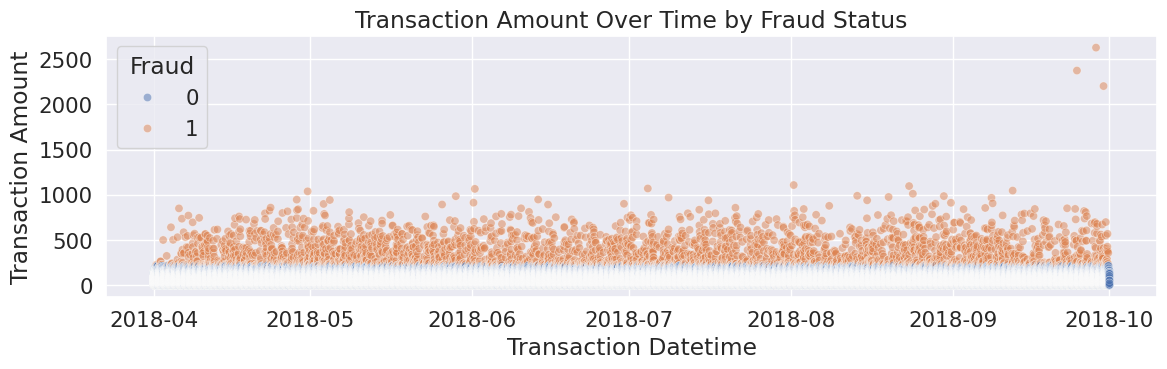

In [ ]:
plt.figure(figsize=(12,4))

sns.scatterplot(
    data=transactions_df,
    x='TX_DATETIME',
    y='TX_AMOUNT',
    hue='TX_FRAUD',
    alpha=0.5
)

plt.title("Transaction Amount Over Time by Fraud Status")
plt.xlabel("Transaction Datetime")
plt.ylabel("Transaction Amount")
plt.legend(title="Fraud")
plt.tight_layout()
plt.show()

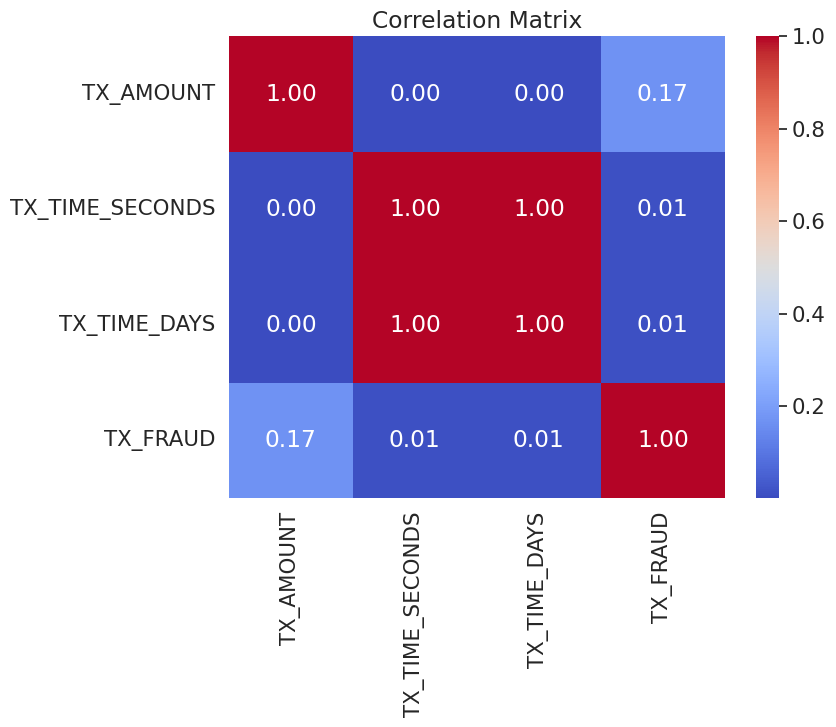

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = transactions_df[
    ['TX_AMOUNT','TX_TIME_SECONDS','TX_TIME_DAYS','TX_FRAUD']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

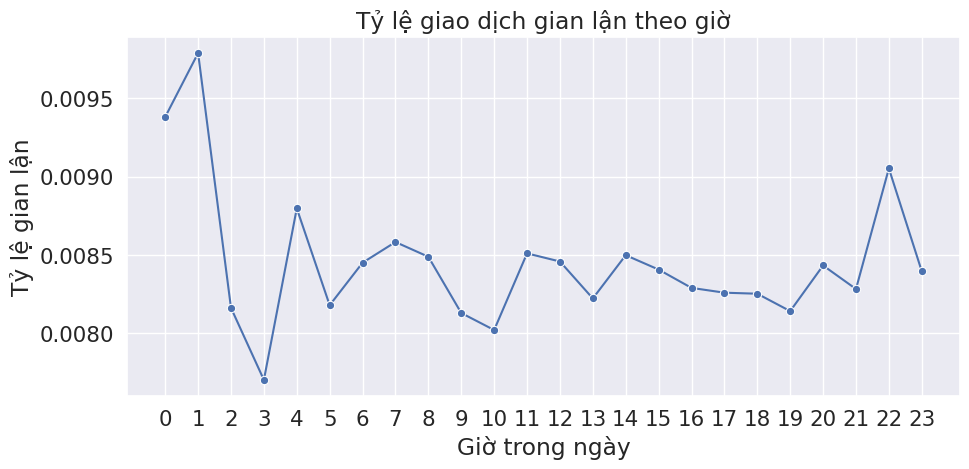

In [ ]:
transactions_df['HOUR'] = transactions_df['TX_DATETIME'].dt.hour
fraud_rate = (
    transactions_df
    .groupby('HOUR')['TX_FRAUD']
    .mean()
    .reset_index(name='Fraud_Rate')
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=fraud_rate,
    x='HOUR',
    y='Fraud_Rate',
    marker='o'
)

plt.title('Tỷ lệ giao dịch gian lận theo giờ')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Tỷ lệ gian lận')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# <font color = "FF6666">3. Baseline feature transformation</font>

### <font color = "green">3.1 Date and time transformations</font>



In [ ]:
transactions_df.drop('HOUR', axis=1, inplace=True)

In [ ]:
def is_weekend(tx_datetime):

    # Transform date into weekday (0 is Monday, 6 is Sunday)
    weekday = tx_datetime.weekday()
    # Binary value: 0 if weekday, 1 if weekend
    is_weekend = weekday>=5

    return int(is_weekend)

In [ ]:
%time transactions_df['TX_DURING_WEEKEND']=transactions_df.TX_DATETIME.apply(is_weekend)

CPU times: user 3.2 s, sys: 157 ms, total: 3.36 s
Wall time: 3.41 s


In [ ]:
def is_night(tx_datetime):

    # Get the hour of the transaction
    tx_hour = tx_datetime.hour
    # Binary value: 1 if hour less than 6, and 0 otherwise
    is_night = tx_hour<=6

    return int(is_night)

In [ ]:
%time transactions_df['TX_DURING_NIGHT']=transactions_df.TX_DATETIME.apply(is_night)

CPU times: user 2.21 s, sys: 130 ms, total: 2.34 s
Wall time: 2.33 s


In [ ]:
transactions_df[transactions_df.TX_TIME_DAYS>=30]

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT
288062,288062,2018-05-01 00:01:21,3546,2944,18.71,2592081,30,0,0,0,1
288063,288063,2018-05-01 00:01:48,206,3521,18.60,2592108,30,0,0,0,1
288064,288064,2018-05-01 00:02:22,2610,4470,66.67,2592142,30,0,0,0,1
288065,288065,2018-05-01 00:03:15,4578,1520,79.41,2592195,30,0,0,0,1
288066,288066,2018-05-01 00:03:51,1246,7809,52.08,2592231,30,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,1,0
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,1,0
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,1,0
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,1,0


### <font color = "green">3.2 Customer ID transformations</font>



In [ ]:
def get_customer_spending_behaviour_features(customer_transactions, windows_size_in_days=[1,7,30]):

    # Let us first order transactions chronologically
    customer_transactions=customer_transactions.sort_values('TX_DATETIME')

    # The transaction date and time is set as the index, which will allow the use of the rolling function
    customer_transactions.index=customer_transactions.TX_DATETIME

    # For each window size
    for window_size in windows_size_in_days:

        # Compute the sum of the transaction amounts and the number of transactions for the given window size
        SUM_AMOUNT_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').sum()
        NB_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').count()

        # Compute the average transaction amount for the given window size
        # NB_TX_WINDOW is always >0 since current transaction is always included
        AVG_AMOUNT_TX_WINDOW=SUM_AMOUNT_TX_WINDOW/NB_TX_WINDOW

        # Save feature values
        customer_transactions['CUSTOMER_ID_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        customer_transactions['CUSTOMER_ID_AVG_AMOUNT_'+str(window_size)+'DAY_WINDOW']=list(AVG_AMOUNT_TX_WINDOW)

    # Reindex according to transaction IDs
    customer_transactions.index=customer_transactions.TRANSACTION_ID

    # And return the dataframe with the new features
    return customer_transactions

In [ ]:
%time transactions_df=transactions_df.groupby('CUSTOMER_ID').apply(lambda x: get_customer_spending_behaviour_features(x, windows_size_in_days=[1,7,30]))
transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)

CPU times: user 30.2 s, sys: 250 ms, total: 30.5 s
Wall time: 30.8 s


In [ ]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT,CUSTOMER_ID_NB_TX_1DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,1,1,1.0,57.160000,1.0,57.160000,1.0,57.160000
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,1,1,1.0,81.510000,1.0,81.510000,1.0,81.510000
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,1,1,1.0,146.000000,1.0,146.000000,1.0,146.000000
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0,1,1,1.0,64.490000,1.0,64.490000,1.0,64.490000
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0,1,1,1.0,50.990000,1.0,50.990000,1.0,50.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,1,0,2.0,75.280000,12.0,67.047500,72.0,69.521111
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,1,0,1.0,1.230000,21.0,22.173810,93.0,24.780753
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,1,0,5.0,7.368000,21.0,7.400476,65.0,7.864462
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,1,0,3.0,100.696667,16.0,107.052500,51.0,102.919608


### <font color = "green">3.3 Terminal ID transformations</font>



In [ ]:
def get_count_risk_rolling_window(terminal_transactions, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"):

    terminal_transactions=terminal_transactions.sort_values('TX_DATETIME')

    terminal_transactions.index=terminal_transactions.TX_DATETIME

    NB_FRAUD_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').sum()
    NB_TX_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').count()

    for window_size in windows_size_in_days:

        NB_FRAUD_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').sum()
        NB_TX_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').count()

        NB_FRAUD_WINDOW=NB_FRAUD_DELAY_WINDOW-NB_FRAUD_DELAY
        NB_TX_WINDOW=NB_TX_DELAY_WINDOW-NB_TX_DELAY

        RISK_WINDOW=NB_FRAUD_WINDOW/NB_TX_WINDOW

        terminal_transactions[feature+'_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        terminal_transactions[feature+'_RISK_'+str(window_size)+'DAY_WINDOW']=list(RISK_WINDOW)

    terminal_transactions.index=terminal_transactions.TRANSACTION_ID

    # Replace NA values with 0 (all undefined risk scores where NB_TX_WINDOW is 0)
    terminal_transactions.fillna(0,inplace=True)

    return terminal_transactions

In [ ]:
%time transactions_df=transactions_df.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"))
transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)

CPU times: user 1min 9s, sys: 267 ms, total: 1min 9s
Wall time: 1min 12s


In [ ]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,1,...,1.0,57.160000,1.0,57.160000,0.0,0.0,0.0,0.0,0.0,0.00000
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,1,...,1.0,81.510000,1.0,81.510000,0.0,0.0,0.0,0.0,0.0,0.00000
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,1,...,1.0,146.000000,1.0,146.000000,0.0,0.0,0.0,0.0,0.0,0.00000
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0,1,...,1.0,64.490000,1.0,64.490000,0.0,0.0,0.0,0.0,0.0,0.00000
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0,1,...,1.0,50.990000,1.0,50.990000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,1,...,12.0,67.047500,72.0,69.521111,1.0,0.0,4.0,0.0,28.0,0.00000
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,1,...,21.0,22.173810,93.0,24.780753,1.0,0.0,9.0,0.0,39.0,0.00000
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,1,...,21.0,7.400476,65.0,7.864462,1.0,0.0,5.0,0.0,33.0,0.00000
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,1,...,16.0,107.052500,51.0,102.919608,1.0,0.0,6.0,0.0,28.0,0.00000


### <font color = "green">3.4 Saving of dataset</font>



In [ ]:
# DIR_OUTPUT = "./simulated-data-transformed/"

# if not os.path.exists(DIR_OUTPUT):
#     os.makedirs(DIR_OUTPUT)

# start_date = datetime.datetime.strptime("2018-04-01", "%Y-%m-%d")

# for day in range(transactions_df.TX_TIME_DAYS.max()+1):

#     transactions_day = transactions_df[transactions_df.TX_TIME_DAYS==day].sort_values('TX_TIME_SECONDS')

#     date = start_date + datetime.timedelta(days=day)
#     filename_output = date.strftime("%Y-%m-%d")+'.pkl'

#     # Protocol=4 required for Google Colab
#     transactions_day.to_pickle(DIR_OUTPUT+filename_output, protocol=4)

https://github.com/Fraud-Detection-Handbook/simulated-data-transformed

# <font color = "FF6666">4. Defining the training, validation and test sets</font>

In [9]:
# Load shared functions
#!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

In [10]:
# tải dữ liệu sau khi đã được tiền xử lý
DIR_INPUT='2_Fraud-detection-handbook_simulated-data-transformed/data/'

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

transactions_df.head(3)

Load  files
CPU times: user 722 ms, sys: 1.35 s, total: 2.07 s
Wall time: 9.76 s
919767 transactions loaded, containing 8195 fraudulent transactions


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
0,680886,2018-06-11 00:00:24,3711,8121,75.81,6134424,71,0,0,0,...,34.0,69.421471,124.0,70.598710,2.0,0.0,10.0,0.0,38.0,0.000000
1,680887,2018-06-11 00:00:25,1320,867,101.89,6134425,71,0,0,0,...,27.0,92.666667,117.0,83.699402,1.0,0.0,10.0,0.0,31.0,0.032258
2,680888,2018-06-11 00:01:46,824,7954,44.72,6134506,71,0,0,0,...,23.0,37.035217,80.0,40.290125,2.0,0.0,14.0,0.0,35.0,0.000000


In [11]:
# Set the starting day for the training period, and the deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=7
delta_delay=7
delta_test=7


delta_valid = delta_test

start_date_training_with_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))

(train_df, valid_df)=get_train_test_set(transactions_df,start_date_training_with_valid,
                                       delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

# By default, scales input data
(train_df, valid_df)=scaleData(train_df, valid_df,input_features)

# <font color = "FF6666">5. Sequence Dataset</font>

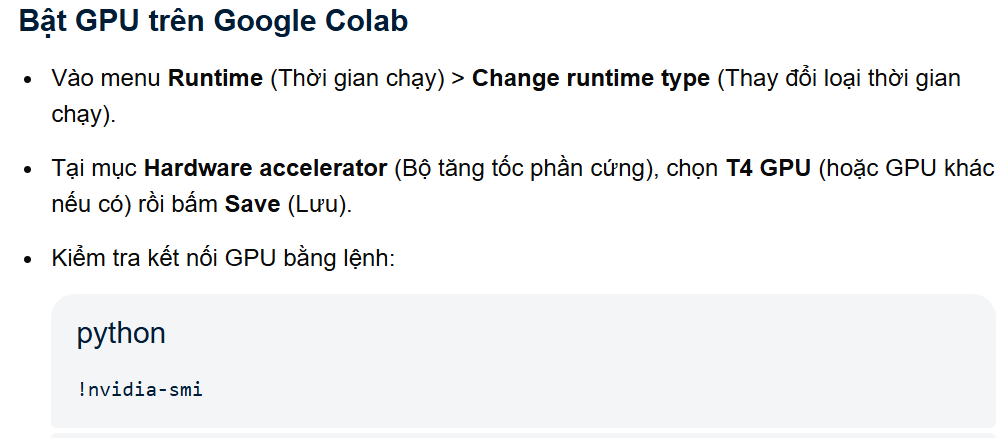

In [12]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [13]:
if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print("Selected device is",DEVICE)

Selected device is cpu


In [14]:
class FraudSequenceDataset(torch.utils.data.Dataset):

    def __init__(self, x,y,customer_ids, dates, seq_len, padding_mode = 'zeros', output=True):
        'Initialization'

        # x,y,customer_ids, and dates must have the same length

        # storing the features x in self.features and adding the "padding" transaction at the end
        if padding_mode == "mean":
            self.features = torch.vstack([x, x.mean(axis=0)])
        elif padding_mode == "zeros":
            self.features = torch.vstack([x, torch.zeros(x[0,:].shape)])
        else:
            raise ValueError('padding_mode must be "mean" or "zeros"')
        self.y = y
        self.customer_ids = customer_ids
        self.dates = dates
        self.seq_len = seq_len
        self.output = output

        #===== computing sequences ids =====


        df_ids_dates = pd.DataFrame({'CUSTOMER_ID':customer_ids,
        'TX_DATETIME':dates})

        df_ids_dates["tmp_index"]  = np.arange(len(df_ids_dates))
        df_groupby_customer_id = df_ids_dates.groupby("CUSTOMER_ID")
        sequence_indices = pd.DataFrame(
            {
                "tx_{}".format(n): df_groupby_customer_id["tmp_index"].shift(seq_len - n - 1)
                for n in range(seq_len)
            }
        )

        #replaces -1 (padding) with the index of the padding transaction (last index of self.features)
        self.sequences_ids = sequence_indices.fillna(len(self.features) - 1).values.astype(int)


    def __len__(self):
        'Denotes the total number of samples'
        # not len(self.features) because of the added padding transaction
        return len(self.customer_ids)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index

        tx_ids = self.sequences_ids[index]

        if self.output:
            #transposing because the CNN considers the channel dimension before the sequence dimension
            return self.features[tx_ids,:].transpose(0,1).to(DEVICE), self.y[index].to(DEVICE)
        else:
            return self.features[tx_ids,:].transpose(0,1).to(DEVICE)

# <font color = "FF6666">6. Long Short-Term Memory network with Attention</font>

In [15]:
# source : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

import torch.nn.functional as F


class Attention(torch.nn.Module):
    r"""
    Applies an attention mechanism on the output features from the decoder.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): The number of expected features in the output
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor containing the output features from the decoder.
        - **context** (batch, input_len, dimensions): tensor containing features of the encoded input sequence.
    Outputs: output, attn
        - **output** (batch, output_len, dimensions): tensor containing the attended output features from the decoder.
        - **attn** (batch, output_len, input_len): tensor containing attention weights.
    Attributes:
        linear_out (torch.nn.Linear): applies a linear transformation to the incoming data: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): applies a :math:`-inf` to the indices specified in the `Tensor`.
    Examples::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Sets indices to be masked
        Args:
            mask (torch.Tensor): tensor containing indices to be masked
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn

In [16]:
class FraudLSTMWithAttention(torch.nn.Module):

        def __init__(self,
                     num_features,
                     hidden_size = 100,
                     hidden_size_lstm = 100,
                     num_layers_lstm = 1,
                     dropout_lstm = 0,
                     attention_out_dim = 100):

            super(FraudLSTMWithAttention, self).__init__()
            # parameters
            self.num_features = num_features
            self.hidden_size = hidden_size

            # sequence representation
            self.lstm = torch.nn.LSTM(self.num_features,
                                      hidden_size_lstm,
                                      num_layers_lstm,
                                      batch_first = True,
                                      dropout = dropout_lstm)

            # layer that will project the last transaction of the sequence into a context vector
            self.ff = torch.nn.Linear(self.num_features, hidden_size_lstm)

            # attention layer
            self.attention = Attention(attention_out_dim)

            #representation to hidden
            self.fc1 = torch.nn.Linear(hidden_size_lstm, self.hidden_size)
            self.relu = torch.nn.ReLU()

            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()

        def forward(self, x):

            #computing the sequence of hidden states from the sequence of transactions
            hidden_states, _ = self.lstm(x.transpose(1,2))

            #computing the context vector from the last transaction
            context_vector = self.ff(x[:,:,-1:].transpose(1,2))

            combined_state, attn = self.attention(context_vector, hidden_states)


            hidden = self.fc1(combined_state[:,0,:])
            relu = self.relu(hidden)

            output = self.fc2(relu)
            output = self.sigmoid(output)

            return output

In [17]:
x_train = torch.FloatTensor(train_df[input_features].values)
x_valid = torch.FloatTensor(valid_df[input_features].values)
y_train = torch.FloatTensor(train_df[output_feature].values)
y_valid = torch.FloatTensor(valid_df[output_feature].values)

seq_len = 5

In [18]:
SEED = 42
seed_everything(SEED)

training_set = FraudSequenceDataset(x_train,
                                    y_train,train_df['CUSTOMER_ID'].values,
                                    train_df['TX_DATETIME'].values,
                                    seq_len,
                                    padding_mode = "zeros")

valid_set = FraudSequenceDataset(x_valid,
                                 y_valid,
                                 valid_df['CUSTOMER_ID'].values,
                                 valid_df['TX_DATETIME'].values,
                                 seq_len,
                                 padding_mode = "zeros")

training_generator,valid_generator = prepare_generators(training_set, valid_set, batch_size=64)

lstm_attn = FraudLSTMWithAttention(x_train.shape[1]).to(DEVICE)
lstm_attn

FraudLSTMWithAttention(
  (lstm): LSTM(15, 100, batch_first=True)
  (ff): Linear(in_features=15, out_features=100, bias=True)
  (attention): Attention(
    (linear_out): Linear(in_features=200, out_features=100, bias=True)
  )
  (fc1): Linear(in_features=100, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [19]:
training_generator,valid_generator = prepare_generators(training_set,valid_set,batch_size=64)

optimizer = torch.optim.Adam(lstm_attn.parameters(), lr = 0.00008)
criterion = torch.nn.BCELoss().to(DEVICE)

lstm_attn,training_execution_time,train_losses_dropout,valid_losses_dropout = \
    training_loop(lstm_attn,
                  training_generator,
                  valid_generator,
                  optimizer,
                  criterion,
                  verbose=True)


Epoch 0: train loss: 0.10345628302892489
valid loss: 0.021702168609366797
New best score: 0.021702168609366797

Epoch 1: train loss: 0.026198113508999747
valid loss: 0.020528789030774777
New best score: 0.020528789030774777

Epoch 2: train loss: 0.024406647935142852
valid loss: 0.01964796919597038
New best score: 0.01964796919597038

Epoch 3: train loss: 0.02337973705218236
valid loss: 0.01951067566266029
New best score: 0.01951067566266029

Epoch 4: train loss: 0.02279390878467883
valid loss: 0.01904716972704427
New best score: 0.01904716972704427

Epoch 5: train loss: 0.022291946048464583
valid loss: 0.0188962607766639
New best score: 0.0188962607766639

Epoch 6: train loss: 0.021782336576510554
valid loss: 0.018766292182428385
New best score: 0.018766292182428385

Epoch 7: train loss: 0.021481877948218923
valid loss: 0.018841431910665757
1  iterations since best score.

Epoch 8: train loss: 0.020978714460524843
valid loss: 0.01868619998201952
New best score: 0.01868619998201952

Ep

In [20]:
############################ lưu lại model ############################

torch.save({
    'model_state_dict': lstm_attn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses_dropout,
    'valid_losses': valid_losses_dropout,
    'training_execution_time': training_execution_time
}, "Tham_lstm_attn_checkpoint.pth")

print("Checkpoint đã được lưu thành công!")

Checkpoint đã được lưu thành công!


In [21]:
############################ load lại model ############################

# checkpoint = torch.load(
#     "lstm_attn_checkpoint.pth",
#     map_location=DEVICE
# )

# lstm_attn.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# train_losses_dropout = checkpoint['train_losses']
# valid_losses_dropout = checkpoint['valid_losses']

# lstm_attn.to(DEVICE)

# <font color = "FF6666">7. Evaluation</font>

In [22]:
def get_all_predictions(model, generator):
    model.eval()
    all_preds = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # append to all preds
        all_preds.append(y_pred.detach().cpu().numpy())
    return np.vstack(all_preds)

In [23]:
valid_predictions = get_all_predictions(lstm_attn, valid_generator)

predictions_df = valid_df
predictions_df['predictions'] = valid_predictions[:,0]

performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.862,0.658,0.273


# <font color = "FF6666">8. Prequential grid search</font>

In [24]:
class FraudSequenceDatasetForPipe(torch.utils.data.Dataset):

    def __init__(self, x,y):
        'Initialization'
        seq_len=5

        # lets us assume that x[:,-1] are the dates, and x[:,-2] are customer ids, padding_mode is "mean"
        customer_ids = x[:,-2]
        dates  = x[:,-1]

        # storing the features x in self.feature and adding the "padding" transaction at the end
        self.features = torch.FloatTensor(x[:,:-2])

        self.features = torch.vstack([self.features, self.features.mean(axis=0)])

        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)

        self.customer_ids = customer_ids
        self.dates = dates
        self.seq_len = seq_len

        #===== computing sequences ids =====


        df_ids_dates_cpy = pd.DataFrame({'CUSTOMER_ID':customer_ids,
        'TX_DATETIME':dates})

        df_ids_dates_cpy["tmp_index"]  = np.arange(len(df_ids_dates_cpy))
        df_groupby_customer_id = df_ids_dates_cpy.groupby("CUSTOMER_ID")
        sequence_indices = pd.DataFrame(
            {
                "tx_{}".format(n): df_groupby_customer_id["tmp_index"].shift(seq_len - n - 1)
                for n in range(seq_len)
            }
        )
        self.sequences_ids = sequence_indices.fillna(len(self.features) - 1).values.astype(int)

        df_ids_dates_cpy = df_ids_dates_cpy.drop("tmp_index", axis=1)



    def __len__(self):
        'Denotes the total number of samples'
        # not len(self.features) because of the added padding transaction
        return len(self.customer_ids)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index

        tx_ids = self.sequences_ids[index]

        if self.y is not None:
            #transposing because the CNN considers the channel dimension before the sequence dimension
            return self.features[tx_ids,:].transpose(0,1), self.y[index]
        else:
            return self.features[tx_ids,:].transpose(0,1), -1

In [25]:
from skorch import NeuralNetClassifier

# Only keep columns that are needed as argument to custome scoring function
# to reduce serialisation time of transaction dataset
transactions_df_scorer = transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom,
                                                     needs_proba=True,
                                                     top_k=100,
                                                     transactions_df=transactions_df_scorer)

performance_metrics_list_grid = ['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list = ['AUC ROC', 'Average precision', 'Card Precision@100']

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }

n_folds=4
start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)
delta_assessment = delta_valid

In [26]:
class FraudLSTMWithAttention(torch.nn.Module):

    def __init__(self, num_features,hidden_size = 100, hidden_size_lstm = 100, num_layers_lstm = 1,p = 0):
        super(FraudLSTMWithAttention, self).__init__()
        # parameters
        self.num_features = num_features
        self.hidden_size = hidden_size

        # representation learning part
        self.lstm = torch.nn.LSTM(self.num_features, hidden_size_lstm, num_layers_lstm, batch_first = True, dropout = p)

        # last sequence represenation
        self.ff = torch.nn.Linear(self.num_features,hidden_size_lstm)

        attention_out_dim = hidden_size_lstm

        # attention layer
        self.attention = Attention(attention_out_dim)

        #representation to hidden
        self.fc1 = torch.nn.Linear(hidden_size_lstm, self.hidden_size)
        self.relu = torch.nn.ReLU()

        #hidden to output
        self.fc2 = torch.nn.Linear(self.hidden_size, 2)
        self.softmax = torch.nn.Softmax()

        self.dropout = torch.nn.Dropout(p)

    def forward(self, x):

        representation_seq, _ = self.lstm(x.transpose(1,2))

        representation_last = self.ff(x[:,:,-1:].transpose(1,2))

        representation, attn = self.attention(representation_last,representation_seq)


        hidden = self.fc1(representation[:,0,:])
        relu = self.relu(hidden)
        relu = self.dropout(relu)

        output = self.fc2(relu)
        output = self.softmax(output)

        return output

In [ ]:
seed_everything(42)
classifier = NeuralNetClassifier(
    FraudLSTMWithAttention,
    max_epochs=2,
    lr=0.001,
    optimizer=torch.optim.Adam,
    batch_size=64,
    dataset=FraudSequenceDatasetForPipe,
    iterator_train__shuffle=True,
)
classifier.set_params(train_split=False, verbose=0)

parameters = {
    'clf__lr': [0.0001,0.0002,0.001],
    'clf__batch_size': [64,128,256],
    'clf__max_epochs': [5,10,20],
    'clf__module__hidden_size': [500],
    'clf__module__p': [0,0.2,0.4],
    'clf__module__num_features': [int(len(input_features))],
    'clf__module__hidden_size_lstm': [100,200],
}

start_time=time.time()

#these will get normalized but it should still work
transactions_df['TX_DATETIME_TIMESTAMP'] = transactions_df['TX_DATETIME'].apply(lambda x:datetime.datetime.timestamp(x))
input_features_new = input_features + ['CUSTOMER_ID','TX_DATETIME_TIMESTAMP']

performances_df=model_selection_wrapper(transactions_df, classifier,
                                        input_features_new, output_feature,
                                        parameters, scoring,
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train,
                                        delta_delay=delta_delay,
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=10)

execution_time_lstm_attn = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                    str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

# Rename to performances_df_lstm for model performance comparison at the end of this notebook
performances_df_lstm_attn=performances_df

In [ ]:
print(execution_time_lstm_attn)

In [ ]:
summary_performances_lstm_attn=get_summary_performances(performances_df_lstm_attn, parameter_column_name="Parameters summary")
summary_performances_lstm_attn

In [ ]:
parameters_dict=dict(performances_df_lstm_attn['Parameters'])
performances_df_lstm_attn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])
                                   for i in range(len(parameters_dict))]

performances_df_lstm_attn_subset = performances_df_lstm_attn[performances_df_lstm_attn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==128 and x['clf__max_epochs']==10 and x['clf__module__p']==0.2).values]
summary_performances_lstm_attn_subset=get_summary_performances(performances_df_lstm_attn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_attn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_attn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_attn_subset,
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="hidden states size",
                       summary_performances=summary_performances_lstm_attn_subset)

performances_df_lstm_attn_subset = performances_df_lstm_attn[performances_df_lstm_attn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==128 and x['clf__module__hidden_size_lstm']==100 and x['clf__module__p']==0.2).values]
summary_performances_lstm_attn_subset=get_summary_performances(performances_df_lstm_attn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_attn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_attn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_attn_subset,
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_lstm_attn_subset)

parameters_dict=dict(performances_df_lstm_attn['Parameters'])
performances_df_lstm_attn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                    str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

In [ ]:
# saving of results

performances_df_dictionary={
    "LSTM_Attention": performances_df_lstm_attn,
}

execution_times=[execution_time_cnn,execution_time_lstm,execution_time_lstm_attn]

filehandler = open('Tham_performances_model.pkl', 'wb')
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()